## PROJECT FOR THE Regressors

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib

In [2]:
from sklearn.linear_model import LinearRegression , Lasso ,Ridge , ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder , StandardScaler , OrdinalEncoder , MinMaxScaler , PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score ,root_mean_squared_error , accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/eco-friendly-product-dataset.csv")

In [4]:
df

,Unnamed: 0,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter
0,0,02-01-2022,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,2022Q1
1,1,09-01-2022,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,2022Q1
2,2,16-01-2022,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,2022Q1
3,3,23-01-2022,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,2022Q1
4,4,30-01-2022,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,2022Q1
...,...,...,...,...,...,...,...,...,...,...
623,623,01-12-2024,West,31.000074,47.662804,47.235254,122.493353,1,441.100930,2024Q4
624,624,08-12-2024,West,35.341897,79.061813,92.526726,135.844589,0,499.099269,2024Q4
625,625,15-12-2024,West,30.994748,79.742460,40.328455,143.787383,0,500.565322,2024Q4
626,626,22-12-2024,West,40.249060,70.010242,64.437233,136.029077,0,449.505525,2024Q4


In [5]:
df = df.drop("Unnamed: 0",axis=1)

In [6]:
df

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter
0,02-01-2022,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,2022Q1
1,09-01-2022,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,2022Q1
2,16-01-2022,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,2022Q1
3,23-01-2022,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,2022Q1
4,30-01-2022,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,2022Q1
...,...,...,...,...,...,...,...,...,...
623,01-12-2024,West,31.000074,47.662804,47.235254,122.493353,1,441.100930,2024Q4
624,08-12-2024,West,35.341897,79.061813,92.526726,135.844589,0,499.099269,2024Q4
625,15-12-2024,West,30.994748,79.742460,40.328455,143.787383,0,500.565322,2024Q4
626,22-12-2024,West,40.249060,70.010242,64.437233,136.029077,0,449.505525,2024Q4


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   week_start          628 non-null    object 
 1   region              628 non-null    object 
 2   avg_temp            628 non-null    float64
 3   google_trend_score  628 non-null    float64
 4   marketing_spend     628 non-null    float64
 5   store_visits        628 non-null    float64
 6   holiday_flag        628 non-null    int64  
 7   sales               628 non-null    float64
 8   quarter             628 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 44.3+ KB


In [8]:
df["week_start"] = pd.to_datetime(df["week_start"],dayfirst=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   week_start          628 non-null    datetime64[ns]
 1   region              628 non-null    object        
 2   avg_temp            628 non-null    float64       
 3   google_trend_score  628 non-null    float64       
 4   marketing_spend     628 non-null    float64       
 5   store_visits        628 non-null    float64       
 6   holiday_flag        628 non-null    int64         
 7   sales               628 non-null    float64       
 8   quarter             628 non-null    object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 44.3+ KB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

,0
week_start,0
region,0
avg_temp,0
google_trend_score,0
marketing_spend,0
store_visits,0
holiday_flag,0
sales,0
quarter,0


In [12]:
df["year"] = df["week_start"].dt.year
df["month"] = df["week_start"].dt.month_name()

In [13]:
df

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter,year,month
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,2022Q1,2022,January
1,2022-01-09,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,2022Q1,2022,January
2,2022-01-16,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,2022Q1,2022,January
3,2022-01-23,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,2022Q1,2022,January
4,2022-01-30,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,2022Q1,2022,January
...,...,...,...,...,...,...,...,...,...,...,...
623,2024-12-01,West,31.000074,47.662804,47.235254,122.493353,1,441.100930,2024Q4,2024,December
624,2024-12-08,West,35.341897,79.061813,92.526726,135.844589,0,499.099269,2024Q4,2024,December
625,2024-12-15,West,30.994748,79.742460,40.328455,143.787383,0,500.565322,2024Q4,2024,December
626,2024-12-22,West,40.249060,70.010242,64.437233,136.029077,0,449.505525,2024Q4,2024,December


In [14]:
df["quarter"] = "Q"+ df["week_start"].dt.quarter.astype("str")

In [15]:
df["quarter"].value_counts()

,count
quarter,
Q4,160
Q1,156
Q2,156
Q3,156


In [16]:
df.head()

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter,year,month
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,Q1,2022,January
1,2022-01-09,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,Q1,2022,January
2,2022-01-16,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,Q1,2022,January
3,2022-01-23,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,Q1,2022,January
4,2022-01-30,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,Q1,2022,January


In [17]:
df.describe()

,week_start,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,year
count,628,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000
mean,2023-07-02 00:00:00,24.986046,71.788369,50.601523,146.670486,0.181529,531.869402,2023.000000
min,2022-01-02 00:00:00,-3.707696,20.000000,-11.654688,100.320913,0.000000,423.263286,2022.000000
25%,2022-10-02 00:00:00,19.558428,61.802410,35.745655,133.672368,0.000000,487.488359,2022.000000
50%,2023-07-02 00:00:00,25.770820,72.039636,51.292144,146.309609,0.000000,515.715335,2023.000000
75%,2024-03-31 00:00:00,31.166459,81.646194,64.860207,159.443478,0.000000,579.248010,2024.000000
max,2024-12-29 00:00:00,44.825052,100.000000,116.255308,202.855078,1.000000,702.612738,2024.000000
std,NaN,8.120082,14.660826,21.721709,17.728933,0.385763,60.638006,0.814541


In [18]:
col = df.select_dtypes(include=float).columns
col

Index(['avg_temp', 'google_trend_score', 'marketing_spend', 'store_visits',
       'sales'],
      dtype='object')

## Outlier Detection

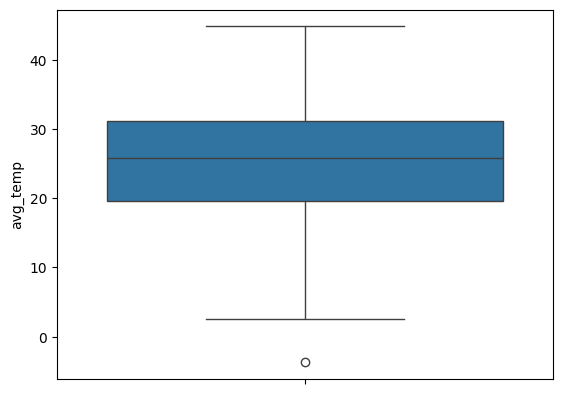

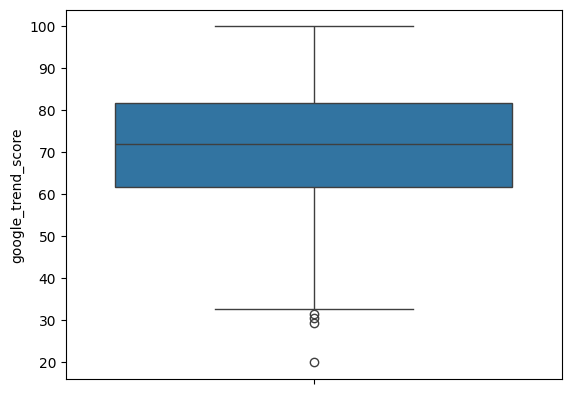

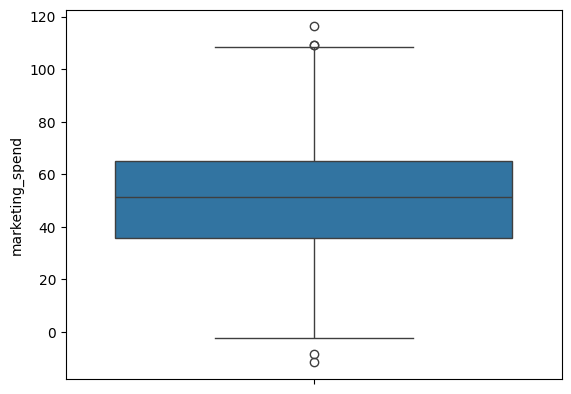

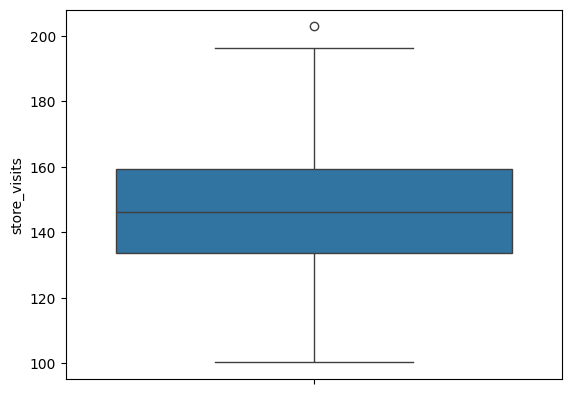

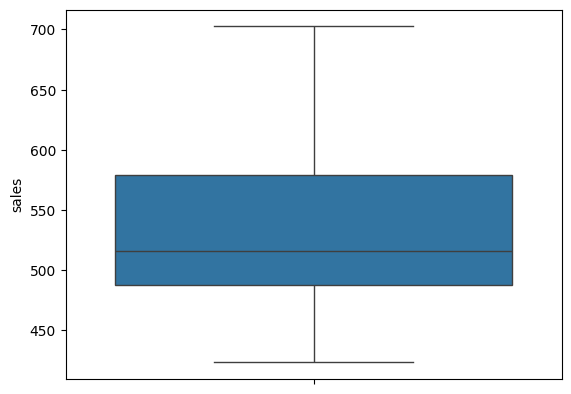

In [19]:
for i in col:
  sns.boxplot(df[i])
  plt.show()

In [20]:
for i in col:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)

  iqr = q3 - q1

  lower = q1 - (iqr * 1.5)
  upper = q3 + (iqr * 1.5)

  df  = df[(df[i] > lower) & (df[i] < upper)]

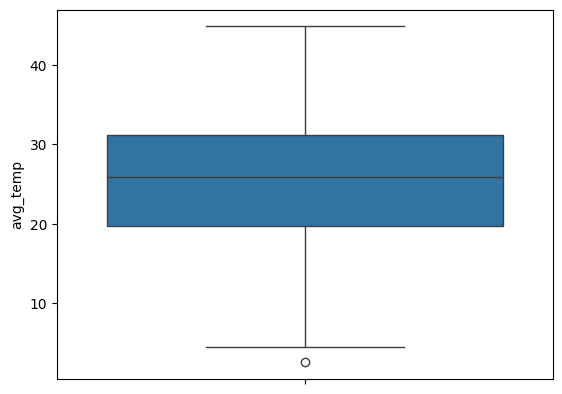

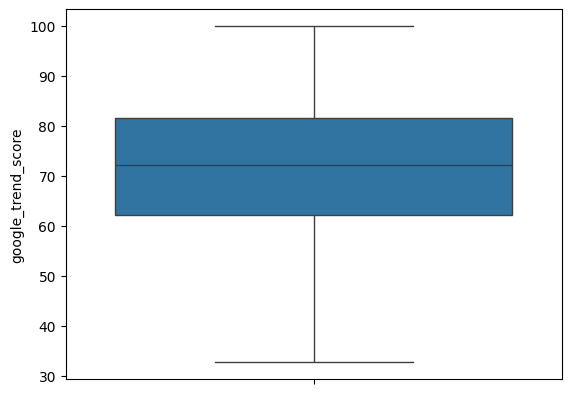

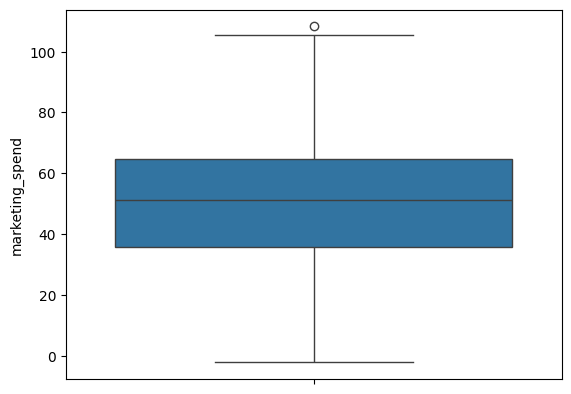

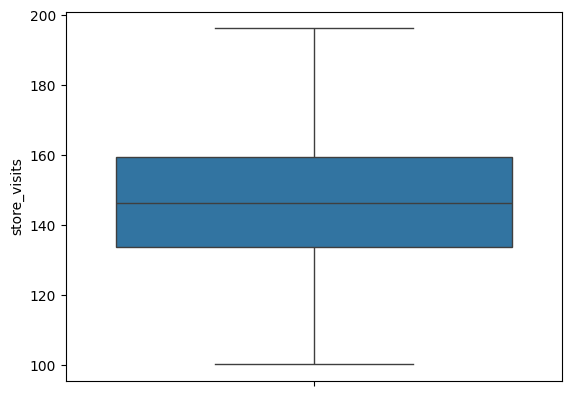

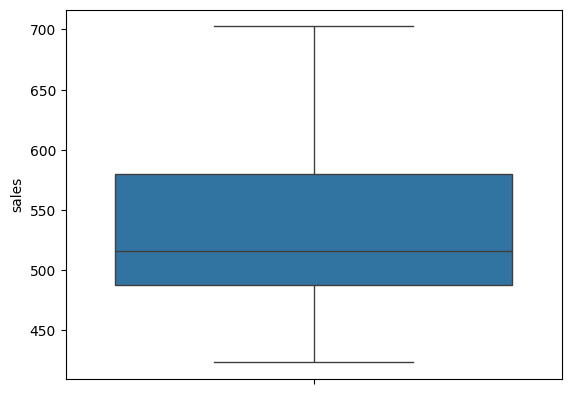

In [21]:
for i in col:
  sns.boxplot(df[i])
  plt.show()

EDA

In [22]:
t=df.groupby('year')['sales'].sum().reset_index()
fig = px.bar(t, x='year', y='sales', title='Total Sales by Year',text_auto=True)
fig.update_xaxes(dtick=1)
fig.show()

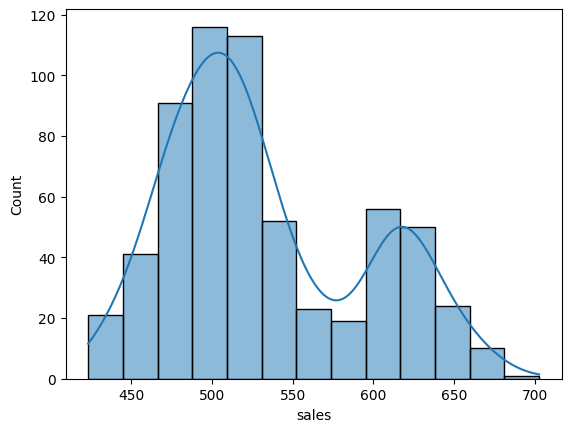

In [23]:
sns.histplot(df["sales"],kde = True)
plt.show()

In [24]:
t = df.groupby(["year","month"])["sales"].sum().reset_index()
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

t["month"] = pd.Categorical(
    t["month"],
    categories=month_order,
    ordered=True
)

t = t.sort_values(["year", "month"])

In [25]:
t.head()

,year,month,sales
4,2022,January,10723.098020
3,2022,February,8625.683105
7,2022,March,8619.054908
0,2022,April,8521.484077
8,2022,May,9638.401472


In [26]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

t = (
    df.groupby(['year', 'month'], as_index=False)['sales']
      .sum()
)

t['month'] = pd.Categorical(
    t['month'],
    categories=month_order,
    ordered=True
)

t = t.sort_values(['year', 'month'])


In [27]:
fig = px.line(t,x='month',y='sales',color='year',markers=True,category_orders={'month': month_order})

fig.update_layout(
    title='Month-wise Sales by Year',
    xaxis_title='Month',
    yaxis_title='Sales',
    hovermode='x unified'
)

fig.show()

In [28]:
t=df.groupby('region')['sales'].sum().reset_index()
t
fig = px.pie(t, names='region', values='sales')
fig.show()

In [29]:
t = df.groupby("quarter")["sales"].sum().reset_index()
fig = px.bar(t, x = "quarter" ,y = "sales")
fig.show()

In [30]:
col = ["avg_temp","google_trend_score","marketing_spend","store_visits","holiday_flag","sales"]

corr  = df[col].corr()

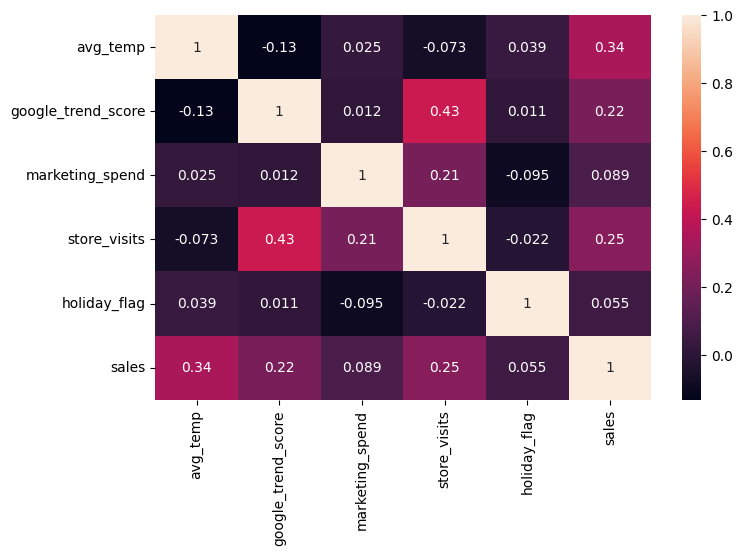

In [31]:
plt.figure(figsize=(8,5))
sns.heatmap(corr,annot=True)
plt.show()

<Figure size 1000x800 with 0 Axes>

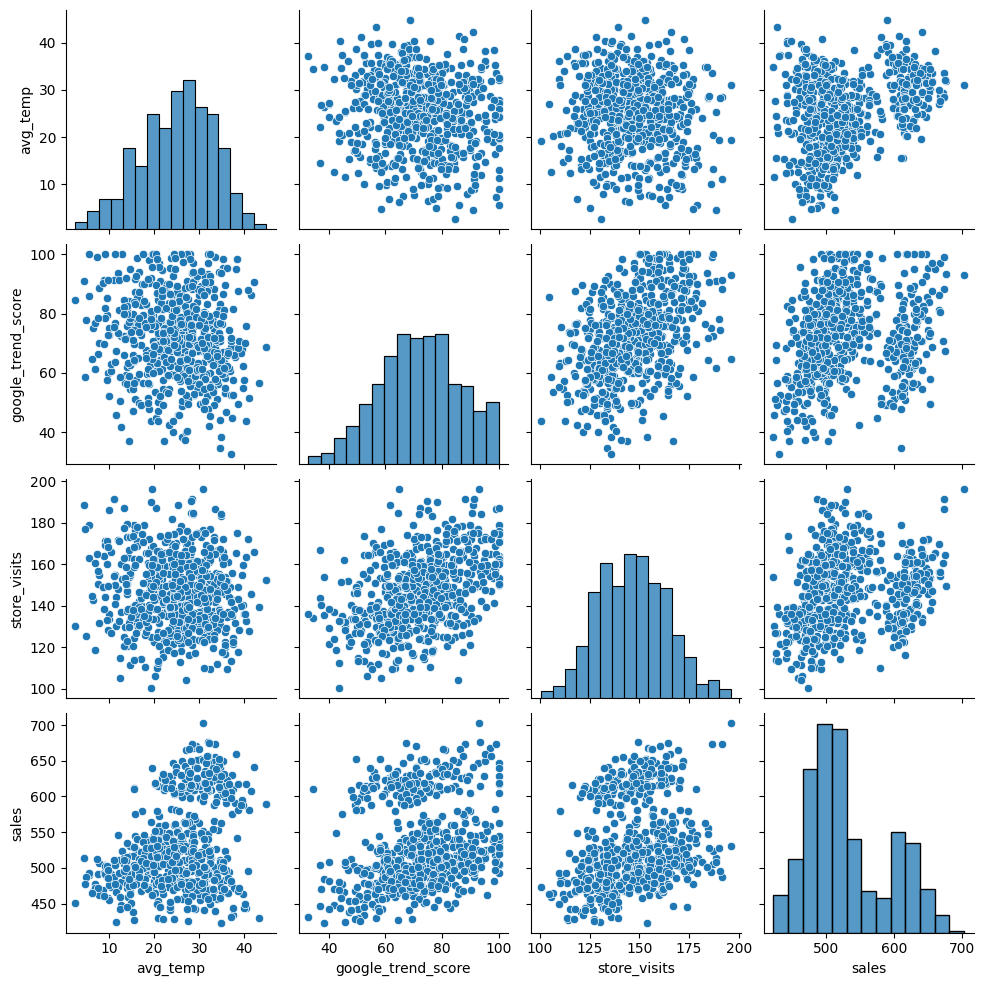

In [32]:
col = ["avg_temp","google_trend_score","store_visits","sales"]

plt.figure(figsize=(10,8))
sns.pairplot(
    df[col],
    diag_kind="hist"
)

plt.show()

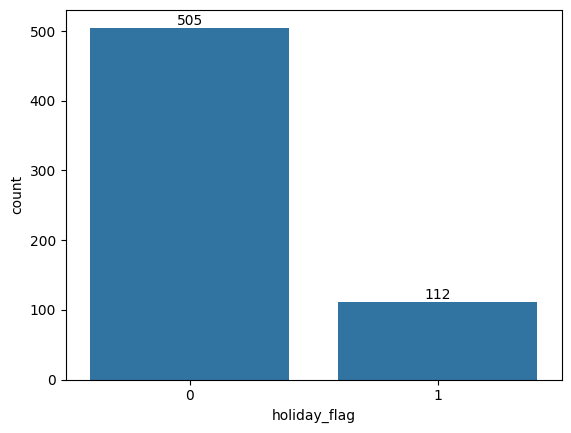

In [33]:
ax = sns.countplot(data=df, x='holiday_flag')
plt.bar_label(ax.containers[0])
plt.show()

---
Feature Engineering
---
---

In [34]:
df.head()

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter,year,month
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,Q1,2022,January
1,2022-01-09,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,Q1,2022,January
2,2022-01-16,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,Q1,2022,January
3,2022-01-23,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,Q1,2022,January
4,2022-01-30,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,Q1,2022,January


In [35]:
df = df.drop(["year","month","quarter"],axis =1)

In [36]:
X = df.drop(columns=["sales"],axis=1)
y = df["sales"]

In [37]:
class FeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()
        X["week_start"] = pd.to_datetime(X["week_start"])
        # Date Features
        X["year"] = X["week_start"].dt.year
        X["month"] = X["week_start"].dt.month
        X["quarter"] = X["week_start"].dt.quarter
        X["week_no"] = X["week_start"].dt.isocalendar().week.astype(int)
        X["marketing_visit_ratio"] = ( X["marketing_spend"] / (X["store_visits"] + 1))
        X["googlescore_visit_ratio"] = ( X["google_trend_score"] / (X["store_visits"] + 1))

        return X

In [38]:
numercial_feature = ['avg_temp','google_trend_score','marketing_spend','store_visits','holiday_flag']
categoricalial_feature = X.select_dtypes(include="object").columns

In [39]:
numercial_feature

['avg_temp',
 'google_trend_score',
 'marketing_spend',
 'store_visits',
 'holiday_flag']

In [40]:
categoricalial_feature

Index(['region'], dtype='object')

---
## Preprocessing
---

In [41]:
numerical_transformation = Pipeline(
    steps=[
        ("Imputer",SimpleImputer(strategy="median")),
        ("StandarScaler",StandardScaler()),
    ]
)

categoricalial_transformation = Pipeline(
    steps=[
        ("Imputer",SimpleImputer(strategy="most_frequent")),
        ("Encoder",OrdinalEncoder())
    ]
)

preprocessing = ColumnTransformer(
    transformers=[
        ("numerical_transformation",numerical_transformation,numercial_feature),
        ("categoricalial_transformation",categoricalial_transformation,categoricalial_feature)
    ]
)

---
## Train - Test Split
---


In [42]:
x_train , x_test , y_train , y_test = train_test_split(X,y,test_size=.20,random_state=42)
print("Train Size : ",x_train.shape)
print("Test Size : ",x_test.shape)

Train Size :  (493, 7)
Test Size :  (124, 7)


---
Models Pipeline
---
---

In [43]:
lr_regresion = Pipeline(
    steps = [
        ("Feature Engineering",FeatureEngineer()),
        ("preprocessing",preprocessing),
        ("linear_model",LinearRegression())
    ]
)

In [44]:
ploy_regresion = Pipeline(
    steps = [
        ("Feature Engineering",FeatureEngineer()),
        ("preprocessing",preprocessing),
        ("poly_features",PolynomialFeatures(degree=3,include_bias=False)),
        ("linear_model",LinearRegression())
    ]
)

In [45]:
lasso_regresion = Pipeline(
    steps = [
        ("Feature Engineering",FeatureEngineer()),
        ("preprocessing",preprocessing),
        ("lasso_model",Lasso(alpha=3))
    ]
)

In [46]:
ridge_regresion = Pipeline(
    steps = [
        ("Feature Engineering",FeatureEngineer()),
        ("preprocessing",preprocessing),
        ("ridge_model",Ridge(alpha=2))
    ]
)

In [47]:
elasticnet_regresion = Pipeline(
    steps = [
        ("Feature Engineering",FeatureEngineer()),
        ("preprocessing",preprocessing),
        ("elasticnet_model",ElasticNet(alpha=3))
    ]
)

In [48]:
knnregressor = Pipeline(
    steps = [
        ("Feature Engineering",FeatureEngineer()),
        ("preprocessing",preprocessing),
        ("knn_regressor",KNeighborsRegressor(n_neighbors=3))
    ]
)

In [49]:
models = {
    "Linear Regression":lr_regresion,
    "Poly Regression":ploy_regresion,
    "Lasso Regression":lasso_regresion,
    "Ridge Regresion":ridge_regresion,
    "Elasticnet Regression":elasticnet_regresion,
    "Knn Regressor":knnregressor

}

n = x_test.shape[0]
p = x_test.shape[1]

for name ,  model in models.items():
  model.fit(x_train,y_train)
  n = x_test.shape[0]
  p = x_test.shape[1]

  y_pred = model.predict(x_test)

  print()
  print("------------------------------------------")
  print(f"{name}")
  print("------------------------------------------")
  print("MSE",mean_squared_error(y_test,y_pred))
  print("MAE",mean_absolute_error(y_test,y_pred))
  print("RMSE",root_mean_squared_error(y_test,y_pred))
  print("R2SCORE",r2_score(y_test,y_pred))
  r2 = r2_score(y_test,y_pred)
  adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
  print("Adjusted R2 : ",adj_r2)


------------------------------------------
Linear Regression
------------------------------------------
MSE 3025.5789126513205
MAE 43.36229391332018
RMSE 55.00526259051329
R2SCORE 0.1608165167871083
Adjusted R2 :  0.11017613417943384

------------------------------------------
Poly Regression
------------------------------------------
MSE 331.933191086995
MAE 14.020435670404439
RMSE 18.21903375832525
R2SCORE 0.9079340319548108
Adjusted R2 :  0.9023783269865666

------------------------------------------
Lasso Regression
------------------------------------------
MSE 3032.932311758907
MAE 43.629729438071955
RMSE 55.0720647130549
R2SCORE 0.15877695634108724
Adjusted R2 :  0.10801349680994599

------------------------------------------
Ridge Regresion
------------------------------------------
MSE 3023.1189810383476
MAE 43.35071452616741
RMSE 54.98289716846819
R2SCORE 0.161498810668391
Adjusted R2 :  0.11089960096734564

------------------------------------------
Elasticnet Regression
--

In [50]:
ploy_regresion.fit(x_train,y_train)

Pipeline(steps=[('Feature Engineering', FeatureEngineer()),
                ('preprocessing',
                 ColumnTransformer(transformers=[('numerical_transformation',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('StandarScaler',
                                                                   StandardScaler())]),
                                                  ['avg_temp',
                                                   'google_trend_score',
                                                   'marketing_spend',
                                                   'store_visits',
                                                   'holiday_flag']),
                                                 ('categoricalial_transformation',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoder',
                                                                   OrdinalEncoder())]),
                                                  Index(['region'], dtype='object'))])),
                ('poly_features',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('linear_model', LinearRegression())])

In [51]:
import joblib

In [56]:
joblib.dump(ploy_regresion,"/content/drive/MyDrive/Dataset/lr_new.pkl")

['/content/drive/MyDrive/Dataset/lr_new.pkl']

In [55]:
import sklearn
print(sklearn.__version__)

1.6.1
